In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [15]:
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2, horizontal_flip=True)
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    r'..\model\data\PlantVillage',  # Replace with your path
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    r'..\model\data\PlantVillage',  # Replace with your path
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)


Found 1159 images belonging to 4 classes.
Found 1159 images belonging to 4 classes.


In [3]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


c:\Users\vikra\OneDrive\Desktop\croppred2\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [7]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)


NameError: name 'train_generator' is not defined

In [2]:
test_generator = validation_datagen.flow_from_directory(
    '..\model\data\PlantVillage',  # Replace with your path
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

loss, accuracy = model.evaluate(test_generator)
print(f'Test accuracy: {accuracy * 100:.2f}%')


NameError: name 'validation_datagen' is not defined

In [7]:
# Save the trained model using the newer .keras format
model.save('potato_disease_model.keras')


In [1]:
# Load the model using the .keras format
from tensorflow.keras.models import load_model

model = load_model('potato_disease_model.keras')


In [3]:
from tensorflow.keras.preprocessing import image
import numpy as np

def prepare_image(img_path, target_size=(150, 150)):
    # Load the image
    img = image.load_img(img_path, target_size=target_size)
    
    # Convert the image to a numpy array
    img_array = image.img_to_array(img)
    
    # Reshape it to match the input shape required by the model
    img_array = np.expand_dims(img_array, axis=0)
    
    # Rescale the image (if you rescaled during training)
    img_array /= 255.0
    
    return img_array


In [4]:
def predict_disease(model, img_path):
    # Prepare the image
    img_array = prepare_image(img_path)
    
    # Make the prediction
    prediction = model.predict(img_array)
    
    # Output the result
    if prediction[0] > 0.5:
        return "Healthy"
    else:
        return "Diseased"


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Image: 0a79700b-f834-41f5-ae51-6ceda6f67a48___RS_Early.B 8951.JPG - The potato plant is: Diseased


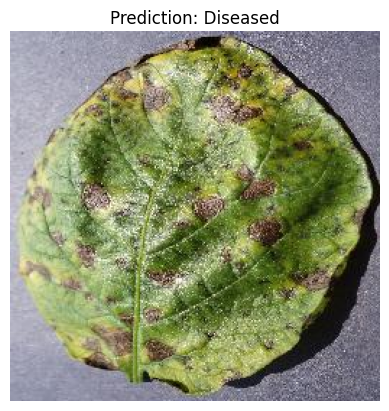

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Image: 5e19b1f4-fd65-4c4d-bcd2-18c8c519eddb___RS_HL 1965.JPG - The potato plant is: Healthy


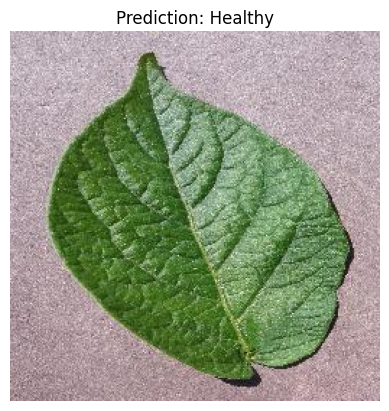

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Image: b475147c-92bc-419a-b2c3-7d5aabbb79ec___RS_Early.B 7379.JPG - The potato plant is: Diseased


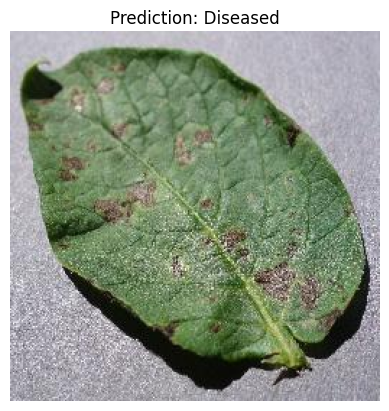

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Image: captured_image.png - The potato plant is: Healthy


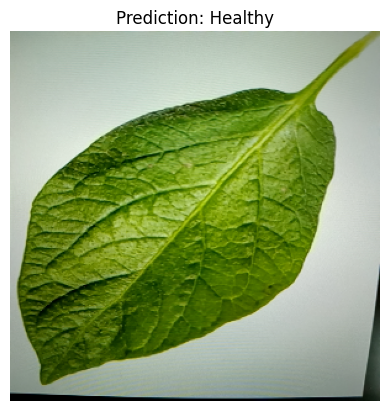

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Image: fresh-green-leaf-potato-plant-isolated-white-background-file-contains-clipping-path-148058712.webp - The potato plant is: Healthy


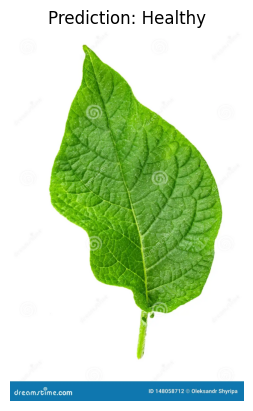

In [5]:
import os
from PIL import Image
import matplotlib.pyplot as plt
def process_upload_folder(upload_folder):
    # Get all files in the upload folder
    for filename in os.listdir(upload_folder):
        file_path = os.path.join(upload_folder, filename)
        
        if os.path.isfile(file_path):
            # Predict each image
            result = predict_disease(model, file_path)
            print(f'Image: {filename} - The potato plant is: {result}')
            
            # Load and display the image
            img = Image.open(file_path)
            plt.imshow(img)
            plt.title(f'Prediction: {result}')
            plt.axis('off')  # Hide axis
            plt.show()

# Path to your upload folder
upload_folder = r'..\model\data\PlantVillage\upload'
process_upload_folder(upload_folder)

In [12]:
# Load the label transformer
import pickle

with open('label_transform.pkl', 'rb') as f:
    label_transform = pickle.load(f)

# Get class names
class_names = label_transform.classes_
print("Class names:", class_names)


Class names: ['Potato___Early_blight' 'Potato___healthy' 'Tomato_Early_blight'
 'Tomato_healthy']


Found 1159 images belonging to 4 classes.
 1/37 ━━━━━━━━━━━━━━━━━━━━ 7s 198ms/step

c:\Users\vikra\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 325ms/step


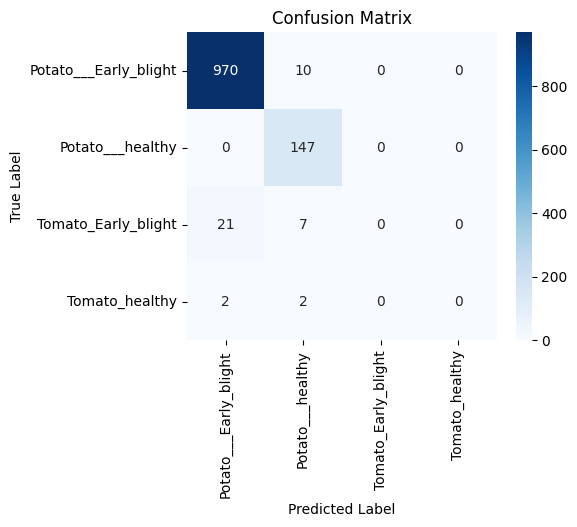

Classification Report:

                       precision    recall  f1-score   support

Potato___Early_blight       0.98      0.99      0.98       980
     Potato___healthy       0.89      1.00      0.94       147
  Tomato_Early_blight       0.00      0.00      0.00        28
       Tomato_healthy       0.00      0.00      0.00         4

             accuracy                           0.96      1159
            macro avg       0.47      0.50      0.48      1159
         weighted avg       0.94      0.96      0.95      1159



c:\Users\vikra\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vikra\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vikra\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

ValueError: multiclass format is not supported

In [16]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Load label transformer
with open('label_transform.pkl', 'rb') as f:
    label_transform = pickle.load(f)

# Get class names
class_names = label_transform.classes_  # ['Diseased', 'Healthy'] (or vice versa)

# Prepare test generator (reloading with shuffle=False is safer for aligned labels)
test_generator = validation_datagen.flow_from_directory(
    r'..\model\data\PlantVillage',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Predict
pred_probs = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
pred_labels = (pred_probs > 0.5).astype(int).flatten()
true_labels = test_generator.classes[:len(pred_labels)]

# CONFUSION MATRIX
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# CLASSIFICATION REPORT
print("Classification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=class_names))

# ROC CURVE
fpr, tpr, _ = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
